In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import os

In [2]:
def f(x):
    return x**2 + 5


def df(x):
    return 2 * x


def ddf(x):
    return 2

In [3]:
# Taken from Assignment 1 pdf
def find_distance_newton(
    x0,
    y0,
    f,
    df,
    ddf,
    initial_guess=0.0,
    tolerance=1e-7,
    max_iter=100,
    log=False,
    history=None,
):
    x = initial_guess

    for i in range(max_iter):
        # history, when given a list, collects each iterate for plotting
        if history is not None:
            history.append(x)

        if log:
            print(
                f"IT#{i + 1}: x = {x:.3f}, f = {f(x):.3f}, f' = {df(x):.3f}, f''= {ddf(x):.3f}"
            )

        # D'(x)
        D_prime = 2 * (x - x0) + 2 * (f(x) - y0) * df(x)

        # D''(x)
        D_double_prime = 2 + 2 * (df(x) ** 2) + 2 * (f(x) - y0) * ddf(x)
        if log:
            print(f"    D' = {D_prime:.3f}, D'' = {D_double_prime:.3f}")

        # Newton-Raphson update step
        next_x = x - D_prime / D_double_prime

        if abs(next_x - x) < tolerance:
            break

        x = next_x
        if log:
            print(f"    new guess: x = {next_x:.3f}")

    shortest_distance = ((x - x0) ** 2 + (f(x) - y0) ** 2) ** 0.5
    return shortest_distance, x

In [4]:
# Taken from Assignment 1 pdf
def golden_section_search(
    x0, y0, f, a, b, tolerance=1e-7, max_iter=100, log=False, history=None
):
    phi = (1 + math.sqrt(5)) / 2
    resphi = 2 - phi

    x1 = a + resphi * (b - a)
    x2 = b - resphi * (b - a)

    def dist_sq(x):
        return (x - x0) ** 2 + (f(x) - y0) ** 2

    f_x1 = dist_sq(x1)
    f_x2 = dist_sq(x2)

    i = 0
    while abs(b - a) > tolerance and i < max_iter:
        i += 1
        # history, when given a list, collects (a, b, x1, x2) for plotting
        if history is not None:
            history.append((a, b, x1, x2))

        if log:
            print(
                f"IT#{i}: [a, b] = [{a:.3f}, {b:.3f}], x1 = {x1:.3f}, D(x1) = {f_x1:.3f}, x2 = {x2:.3f}, D(x2) = {f_x2:.3f}"
            )

        if f_x1 < f_x2:
            b = x2
            x2 = x1
            f_x2 = f_x1
            x1 = a + resphi * (b - a)
            f_x1 = dist_sq(x1)
        else:
            a = x1
            x1 = x2
            f_x1 = f_x2
            x2 = b - resphi * (b - a)
            f_x2 = dist_sq(x2)
        if log:
            print(f"    new interval: [{a:.3f}, {b:.3f}]")

    best_x = (a + b) / 2
    return math.sqrt(dist_sq(best_x)), best_x

In [5]:
def confirm_newtons_byhand():
    points = [(0, 0), (-4, 0), (-8, 0), (2, 0), (6, 0)]

    for point in points:
        print(f"for point: {point}")

        x0 = point[0]
        y0 = point[1]

        find_distance_newton(x0, y0, f, df, ddf, max_iter=2, log=True)

        print(f"\n")

In [6]:
def confirm_golden_byhand():
    cases = [
        ((0, 0), -1, 1),
        ((-4, 0), -4, 0),
        ((-8, 0), -8, 0),
        ((2, 0), 0, 2),
        ((6, 0), 0, 6),
    ]

    for point, a, b in cases:
        print(f"for point: {point}, bracket: [{a}, {b}]")

        x0 = point[0]
        y0 = point[1]

        golden_section_search(x0, y0, f, a, b, max_iter=2, log=True)

        print("\n")

In [7]:
confirm_newtons_byhand()
confirm_golden_byhand()

for point: (0, 0)
IT#1: x = 0.000, f = 5.000, f' = 0.000, f''= 2.000
    D' = 0.000, D'' = 22.000


for point: (-4, 0)
IT#1: x = 0.000, f = 5.000, f' = 0.000, f''= 2.000
    D' = 8.000, D'' = 22.000
    new guess: x = -0.364
IT#2: x = -0.364, f = 5.132, f' = -0.727, f''= 2.000
    D' = -0.192, D'' = 23.587
    new guess: x = -0.355


for point: (-8, 0)
IT#1: x = 0.000, f = 5.000, f' = 0.000, f''= 2.000
    D' = 16.000, D'' = 22.000
    new guess: x = -0.727
IT#2: x = -0.727, f = 5.529, f' = -1.455, f''= 2.000
    D' = -1.539, D'' = 28.347
    new guess: x = -0.673


for point: (2, 0)
IT#1: x = 0.000, f = 5.000, f' = 0.000, f''= 2.000
    D' = -4.000, D'' = 22.000
    new guess: x = 0.182
IT#2: x = 0.182, f = 5.033, f' = 0.364, f''= 2.000
    D' = 0.024, D'' = 22.397
    new guess: x = 0.181


for point: (6, 0)
IT#1: x = 0.000, f = 5.000, f' = 0.000, f''= 2.000
    D' = -12.000, D'' = 22.000
    new guess: x = 0.545
IT#2: x = 0.545, f = 5.298, f' = 1.091, f''= 2.000
    D' = 0.649, D'' 

In [8]:
def find_distance_newtons_method(f, df, ddf, points, initial_guess=0.0):
    for point in points:
        print(f"for point {point}: ")

        x0 = point[0]
        y0 = point[1]

        distance, nearest_x = find_distance_newton(
            x0, y0, f, df, ddf, initial_guess=initial_guess
        )
        nearest_y = f(nearest_x)

        print(f"    shortest distance: {distance:.3f}")
        print(f"    is to point: ({nearest_x:.3f} {nearest_y:.3f})\n")

In [9]:
find_distance_newtons_method(f, df, ddf, [(0, 0), (-4, 0), (-8, 0), (2, 0), (6, 0)])

for point (0, 0): 
    shortest distance: 5.000
    is to point: (0.000 5.000)

for point (-4, 0): 
    shortest distance: 6.290
    is to point: (-0.355 5.126)

for point (-8, 0): 
    shortest distance: 9.133
    is to point: (-0.672 5.452)

for point (2, 0): 
    shortest distance: 5.351
    is to point: (0.181 5.033)

for point (6, 0): 
    shortest distance: 7.603
    is to point: (0.520 5.270)



In [10]:
def find_distance_golden_section_method(f, cases):
    for point, a, b in cases:
        print(f"for point {point}, bracket [{a}, {b}]: ")

        x0 = point[0]
        y0 = point[1]

        distance, nearest_x = golden_section_search(x0, y0, f, a, b)
        nearest_y = f(nearest_x)

        print(f"    shortest distance: {distance:.3f}")
        print(f"    is to point: ({nearest_x:.3f}, {nearest_y:.3f})\n")

In [11]:
find_distance_golden_section_method(
    f,
    [
        ((0, 0), -1, 1),
        ((-4, 0), -4, 0),
        ((-8, 0), -8, 0),
        ((2, 0), 0, 2),
        ((6, 0), 0, 6),
    ],
)

for point (0, 0), bracket [-1, 1]: 
    shortest distance: 5.000
    is to point: (0.000, 5.000)

for point (-4, 0), bracket [-4, 0]: 
    shortest distance: 6.290
    is to point: (-0.355, 5.126)

for point (-8, 0), bracket [-8, 0]: 
    shortest distance: 9.133
    is to point: (-0.672, 5.452)

for point (2, 0), bracket [0, 2]: 
    shortest distance: 5.351
    is to point: (0.181, 5.033)

for point (6, 0), bracket [0, 6]: 
    shortest distance: 7.603
    is to point: (0.520, 5.270)



In [12]:
def make_parabola(a, b, c):
    def f(x):
        return a * x**2 + b * x + c

    def df(x):
        return 2 * a * x + b

    def ddf(x):
        return 2 * a

    return f, df, ddf

In [13]:
parabolas = [
    (
        (2, -4, 1),
        "y = 2x^2 - 4x + 1",
        [((1, -5), 0, 2), ((-2, -3), -2, 1), ((4, -4), 1, 4)],
    ),
    (
        (-0.5, 3, 2),
        "y = -0.5x^2 + 3x + 2",
        [((0, 10), 0, 3), ((3, 9), 2, 4), ((7, 8), 3, 7)],
    ),
    (
        (1, -6, 9),
        "y = x^2 - 6x + 9",
        [((0, -2), 0, 3), ((5, -1), 3, 5), ((-1, 1), -1, 3)],
    ),
]

for coeffs, label, cases in parabolas:
    f_p, df_p, ddf_p = make_parabola(*coeffs)
    points = [point for point, _, _ in cases]

    print(f"===== {label} =====")
    print(f"Newton-Raphson:")
    find_distance_newtons_method(f_p, df_p, ddf_p, points)
    print(f"Golden section:")
    find_distance_golden_section_method(f_p, cases)

===== y = 2x^2 - 4x + 1 =====
Newton-Raphson:
for point (1, -5): 
    shortest distance: 4.000
    is to point: (1.000 -1.000)

for point (-2, -3): 
    shortest distance: 3.470
    is to point: (0.693 -0.811)

for point (4, -4): 
    shortest distance: 4.162
    is to point: (1.224 -0.900)

Golden section:
for point (1, -5), bracket [0, 2]: 
    shortest distance: 4.000
    is to point: (1.000, -1.000)

for point (-2, -3), bracket [-2, 1]: 
    shortest distance: 3.470
    is to point: (0.693, -0.811)

for point (4, -4), bracket [1, 4]: 
    shortest distance: 4.162
    is to point: (1.224, -0.900)

===== y = -0.5x^2 + 3x + 2 =====
Newton-Raphson:
for point (0, 10): 
    shortest distance: 4.393
    is to point: (2.362 6.297)

for point (3, 9): 
    shortest distance: 2.500
    is to point: (3.000 6.500)

for point (7, 8): 
    shortest distance: 3.573
    is to point: (4.229 5.745)

Golden section:
for point (0, 10), bracket [0, 3]: 
    shortest distance: 4.393
    is to point: (2.3

In [14]:
non_polynomials = [
    (
        "y = e^x",
        math.exp,
        math.exp,
        math.exp,
        -1,
        [((1, 0), -1, 1), ((2, 1), 0, 2), ((-2, 3), -2, 0)],
    ),
    (
        "y = ln(x)",
        math.log,
        lambda x: 1 / x,
        lambda x: -1 / x**2,
        0.2,
        [((0, 2), 0.5, 3), ((4, 1), 1, 4), ((-1, -1), 0.05, 1)],
    ),
    (
        "y = 1/x, x > 0",
        lambda x: 1 / x,
        lambda x: -1 / x**2,
        lambda x: 2 / x**3,
        0.5,
        [((0, 0), 0.5, 2), ((3, 1), 1, 3), ((1, 4), 0.1, 1)],
    ),
    (
        "y = sqrt(x)",
        math.sqrt,
        lambda x: 1 / (2 * math.sqrt(x)),
        lambda x: -1 / (4 * x**1.5),
        1,
        [((4, 0), 1, 4), ((1, 3), 1, 3), ((6, 1), 1, 6)],
    ),
]

for label, f_np, df_np, ddf_np, initial_guess, cases in non_polynomials:
    points = [point for point, _, _ in cases]

    print(f"===== {label} =====")
    print("Newton-Raphson:")
    find_distance_newtons_method(f_np, df_np, ddf_np, points, initial_guess)
    print("Golden section:")
    find_distance_golden_section_method(f_np, cases)

===== y = e^x =====
Newton-Raphson:
for point (1, 0): 
    shortest distance: 1.414
    is to point: (0.000 1.000)

for point (2, 1): 
    shortest distance: 1.623
    is to point: (0.583 1.791)

for point (-2, 3): 
    shortest distance: 2.815
    is to point: (-1.151 0.316)

Golden section:
for point (1, 0), bracket [-1, 1]: 
    shortest distance: 1.414
    is to point: (0.000, 1.000)

for point (2, 1), bracket [0, 2]: 
    shortest distance: 1.623
    is to point: (0.583, 1.791)

for point (-2, 3), bracket [-2, 0]: 
    shortest distance: 2.815
    is to point: (-1.151, 0.316)

===== y = ln(x) =====
Newton-Raphson:
for point (0, 2): 
    shortest distance: 2.170
    is to point: (1.314 0.273)

for point (4, 1): 
    shortest distance: 0.375
    is to point: (3.907 1.363)

for point (-1, -1): 
    shortest distance: 1.307
    is to point: (0.264 -1.333)

Golden section:
for point (0, 2), bracket [0.5, 3]: 
    shortest distance: 2.170
    is to point: (1.314, 0.273)

for point (4, 1

In [15]:
BG = "#ffffff"
TEXT = "#000000"
MUTED = "#444444"
GRID = "#dddddd"
CURVE = "#1f4e9c"
POINT = "#b02020"
NEWTON = "#1a7a4c"
RESULT = "#a06000"
GOLDEN = "#8b2f6b"

plt.rcParams.update(
    {
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "savefig.facecolor": BG,
        "axes.edgecolor": TEXT,
        "axes.labelcolor": TEXT,
        "axes.titlecolor": TEXT,
        "text.color": TEXT,
        "xtick.color": TEXT,
        "ytick.color": TEXT,
        "grid.color": GRID,
        "grid.linewidth": 0.6,
        "legend.facecolor": BG,
        "legend.edgecolor": GRID,
        "legend.labelcolor": TEXT,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "legend.fontsize": 7,
        "figure.titlesize": 11,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
    }
)


def evaluate(func, xs):
    ys = []
    for x in xs:
        try:
            ys.append(func(x))
        except (ValueError, ZeroDivisionError):
            ys.append(np.nan)
    return np.array(ys)


def plot_intermediate_steps(
    label,
    f,
    df,
    ddf,
    point,
    initial_guess,
    a,
    b,
    domain=(-np.inf, np.inf),
    filename=None,
):
    x0 = point[0]
    y0 = point[1]

    newton_xs = []
    d_newton, x_newton = find_distance_newton(
        x0, y0, f, df, ddf, initial_guess=initial_guess, history=newton_xs
    )
    if newton_xs[-1] != x_newton:
        newton_xs.append(x_newton)

    brackets = []
    d_golden, x_golden = golden_section_search(x0, y0, f, a, b, history=brackets)

    def D(x):
        return (x - x0) ** 2 + (f(x) - y0) ** 2

    def D_prime(x):
        return 2 * (x - x0) + 2 * (f(x) - y0) * df(x)

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(11, 6.5))
    fig.suptitle(
        "Shortest distance from P(" + str(x0) + ", " + str(y0) + ") to " + label
    )

    print("Newton d =", d_newton, "x =", x_newton, "steps =", len(newton_xs) - 1)
    print("Golden d =", d_golden, "x =", x_golden, "iters =", len(brackets))

    shown = newton_xs[:8]

    # plot 1
    xs_of_interest = [x0, x_newton] + shown
    ys_of_interest = [y0, f(x_newton)] + [f(x) for x in shown]
    lo = min(xs_of_interest) - 1
    hi = max(xs_of_interest) + 1

    grid = np.linspace(max(lo, domain[0] + 0.01), min(hi, domain[1]), 500)
    ax1.plot(grid, evaluate(f, grid), color=CURVE, linewidth=1.5, label=label)
    ax1.plot(x0, y0, "D", color=POINT, markersize=6, label="point P(" + str(x0) + ", " + str(y0) + ")")
    for i in range(len(shown)):
        x = shown[i]
        if i == 0:
            ax1.plot(x, f(x), "o", color=NEWTON, label="Newton iterates")
        else:
            ax1.plot(x, f(x), "o", color=NEWTON)
        if i == 0 or abs(x - shown[i - 1]) > 0.05 * (hi - lo):
            ax1.annotate("x" + str(i), (x, f(x)), textcoords="offset points", xytext=(5, 5))
    ax1.plot([x0, x_newton], [y0, f(x_newton)], "-", color=RESULT, linewidth=1.5, label="shortest distance")
    ax1.plot(x_newton, f(x_newton), "o", color=RESULT, markersize=6, label="closest point, d = " + str(round(d_newton, 3)))
    ax1.set_xlim(lo, hi)
    ax1.set_ylim(min(ys_of_interest) - 1, max(ys_of_interest) + 1)
    ax1.set_title("Newton's method: iterates on curve")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.legend()
    ax1.grid(True)

    # plot 2
    pad = max(0.2 * (max(shown) - min(shown)), 0.1)
    lo2 = max(min(shown) - pad, domain[0] + 0.01)
    hi2 = min(max(shown) + pad, domain[1])
    grid2 = np.linspace(lo2, hi2, 500)
    ax2.axhline(0, color=MUTED, linewidth=0.8)
    ax2.plot(grid2, evaluate(D_prime, grid2), color=CURVE, linewidth=1.5, label="D'(x) = 2(x - x0) + 2(f(x) - y0)f'(x)")
    for i in range(len(shown) - 1):
        x = shown[i]
        x_next = shown[i + 1]
        if i == 0:
            ax2.plot([x, x_next], [D_prime(x), 0], "--", color=NEWTON, label="tangent line to D' = 0")
            ax2.plot([x_next, x_next], [0, D_prime(x_next)], ":", color=MUTED, label="back to D'(x) at next x")
        else:
            ax2.plot([x, x_next], [D_prime(x), 0], "--", color=NEWTON)
            ax2.plot([x_next, x_next], [0, D_prime(x_next)], ":", color=MUTED)
    for i in range(len(shown)):
        x = shown[i]
        ax2.plot(x, D_prime(x), "o", color=NEWTON)
        if i == 0 or abs(x - shown[i - 1]) > 0.05 * (hi2 - lo2):
            ax2.annotate("x" + str(i), (x, D_prime(x)), textcoords="offset points", xytext=(5, 5))

    d_values = [D_prime(x) for x in shown] + [0]
    pad_y = max(0.2 * (max(d_values) - min(d_values)), 0.1)
    ax2.set_ylim(min(d_values) - pad_y, max(d_values) + pad_y)
    ax2.set_title("Newton's method: steps on D'(x)")
    ax2.set_xlabel("x")
    ax2.set_ylabel("D'(x)")
    ax2.legend()
    ax2.grid(True)

    # plot 3
    shown_b = brackets[:8]
    grid3 = np.linspace(a, b, 500)
    ax3.plot(grid3, evaluate(D, grid3), color=CURVE, linewidth=1.5, label="D(x) = (x - x0)^2 + (f(x) - y0)^2")
    for i in range(len(shown_b)):
        a_k, b_k, x1, x2 = shown_b[i]
        if i == 0:
            ax3.plot([x1, x2], [D(x1), D(x2)], "o", color=GOLDEN, label="compared D(x1), D(x2)")
        else:
            ax3.plot([x1, x2], [D(x1), D(x2)], "o", color=GOLDEN)
    ax3.plot(x_golden, D(x_golden), "o", color=RESULT, markersize=6, label="minimum at x = " + str(round(x_golden, 3)))
    ax3.set_title("Golden section: comparisons on D(x)")
    ax3.set_xlabel("x")
    ax3.set_ylabel("D(x)")
    ax3.legend()
    ax3.grid(True)

    # plot 4
    for i in range(len(shown_b)):
        a_k, b_k, x1, x2 = shown_b[i]
        if i == 0:
            ax4.plot([a_k, b_k], [i + 1, i + 1], "-", color=GOLDEN, linewidth=3, label="bracket [a, b]")
            ax4.plot([x1, x2], [i + 1, i + 1], "|", color=TEXT, markersize=8, label="x1, x2")
        else:
            ax4.plot([a_k, b_k], [i + 1, i + 1], "-", color=GOLDEN, linewidth=3)
            ax4.plot([x1, x2], [i + 1, i + 1], "|", color=TEXT, markersize=8)
    ax4.axvline(
        x_golden, color=RESULT, linestyle="--", label="result x = " + str(round(x_golden, 3))
    )
    ax4.set_ylim(len(shown_b) + 0.5, 0.5)
    ax4.set_title("Golden section: brackets (first " + str(len(shown_b)) + " iterations)")
    ax4.set_xlabel("x")
    ax4.set_ylabel("iteration")
    ax4.legend()

    plt.tight_layout()

    if filename:
        os.makedirs("media", exist_ok=True)
        fig.savefig("media/" + filename, dpi=110)
    plt.show()

Newton d = 5.0 x = 0.0 steps = 0
Golden d = 5.0 x = 1.8512169118416442e-08 iters = 35


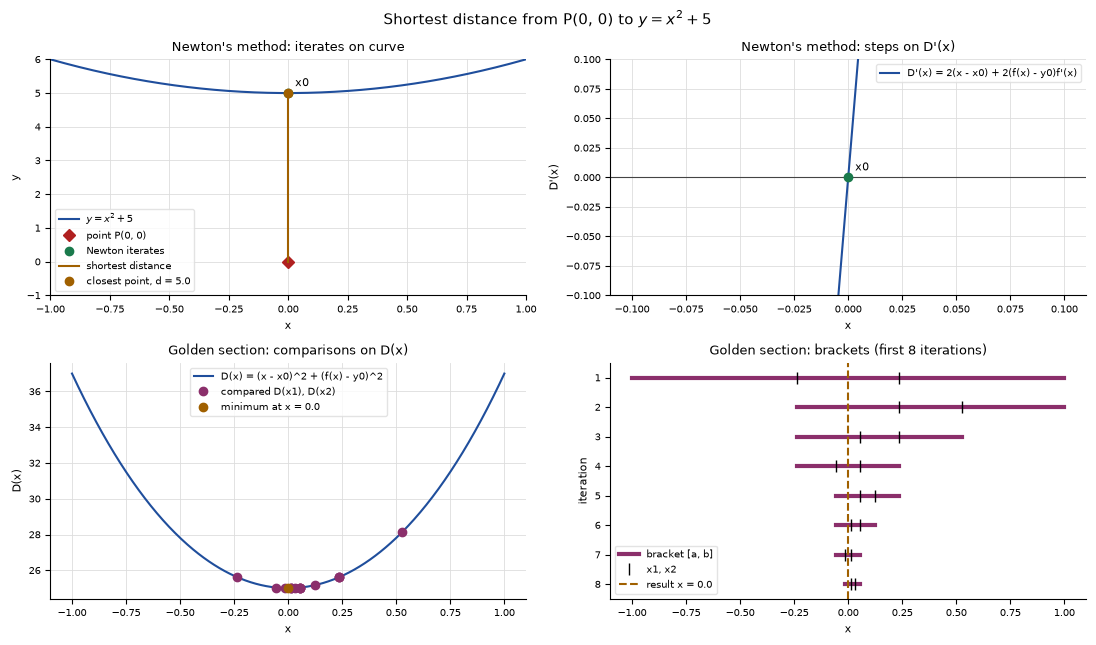

Newton d = 6.289845364298705 x = -0.3554696929020387 steps = 3
Golden d = 6.2898453642987056 x = -0.3554696688204245 iters = 37


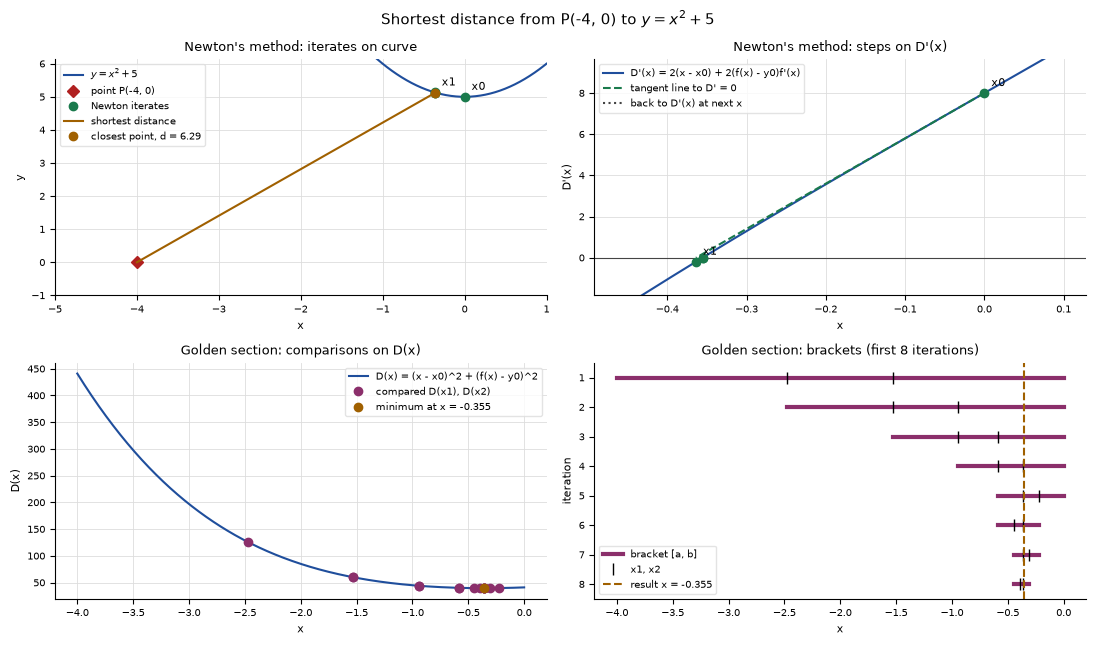

Newton d = 9.133419514364457 x = -0.6720781267789698 steps = 4
Golden d = 9.133419514364455 x = -0.6720781333369705 iters = 38


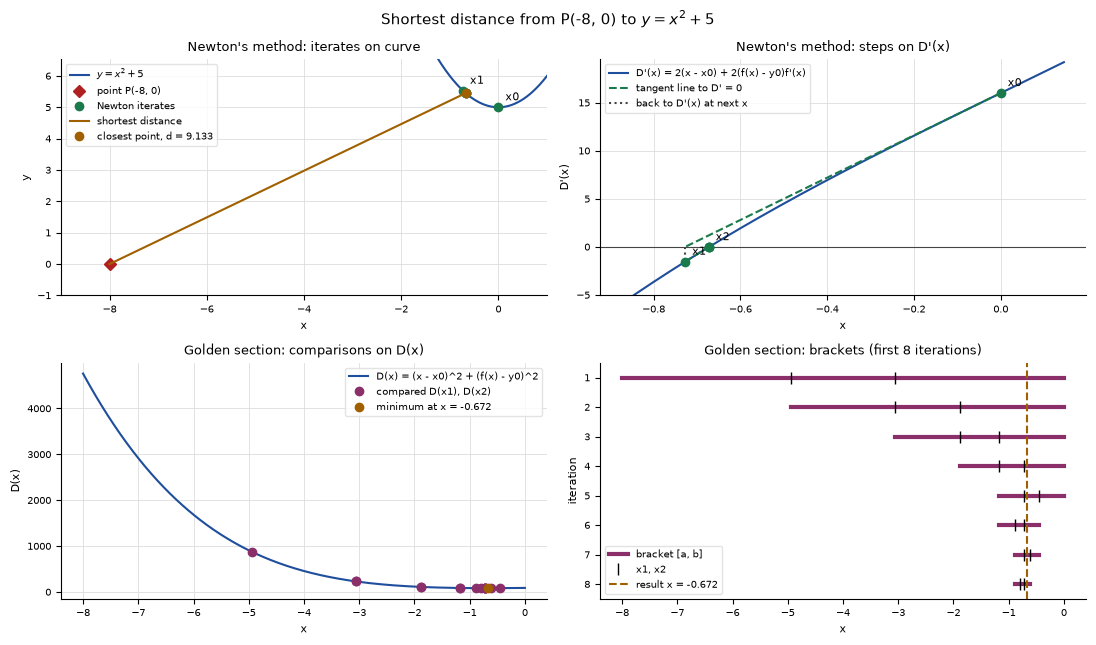

Newton d = 5.351396411482533 x = 0.18074460447935092 steps = 3
Golden d = 5.351396411482534 x = 0.18074461013672682 iters = 35


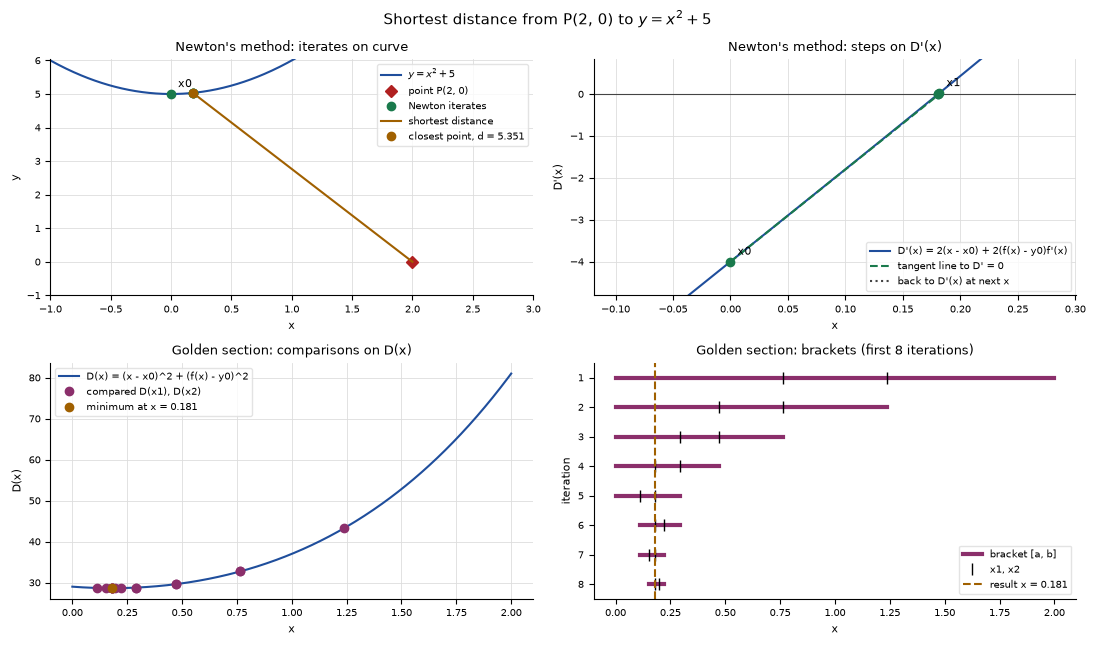

Newton d = 7.60312541280576 x = 0.5199036677238884 steps = 3
Golden d = 7.603125412805761 x = 0.5199036892505743 iters = 38


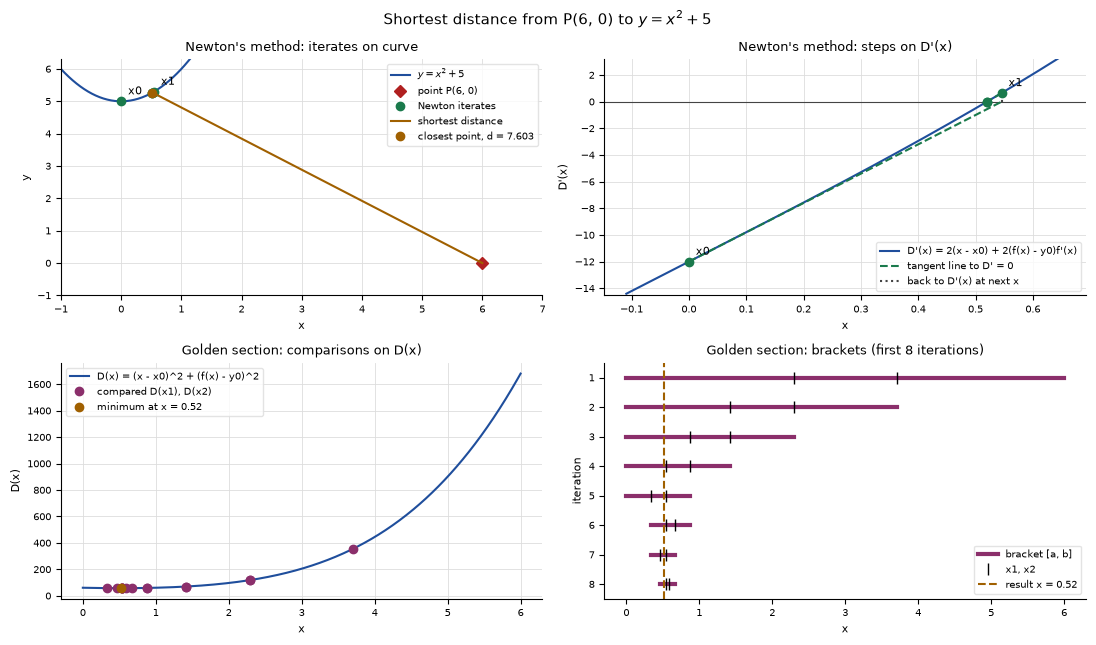

Newton d = 3.4701253272200447 x = 0.6925096168508598 steps = 5
Golden d = 3.4701253272200456 x = 0.6925096005964716 iters = 36


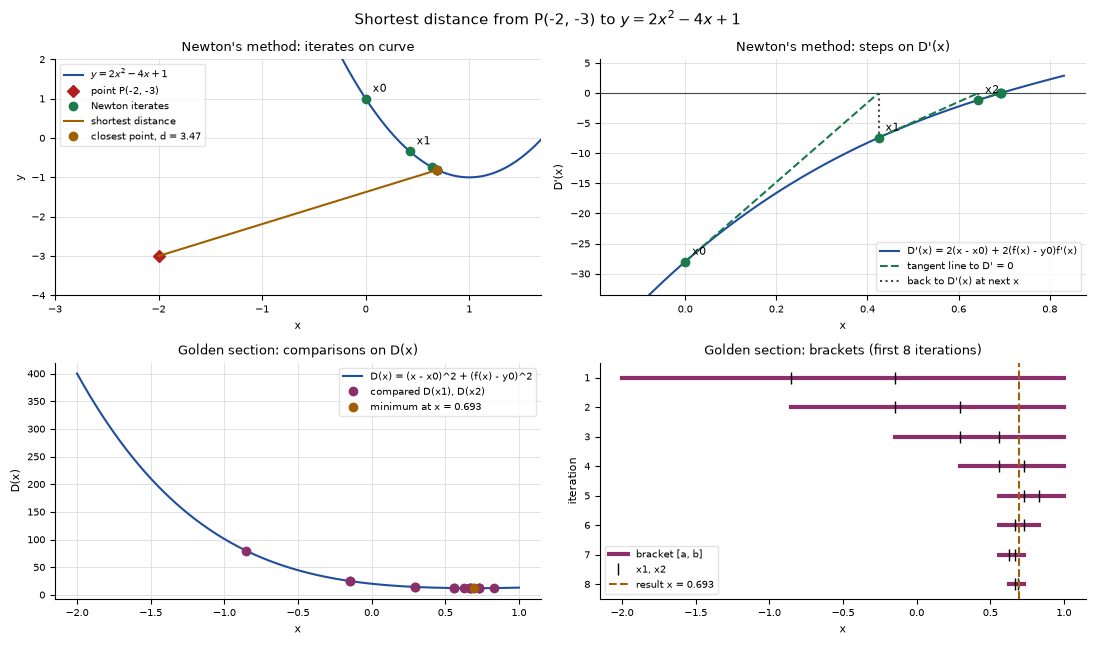

Newton d = 2.8147713482997028 x = -1.151388652008242 steps = 4
Golden d = 2.814771348299703 x = -1.1513886554638528 iters = 35


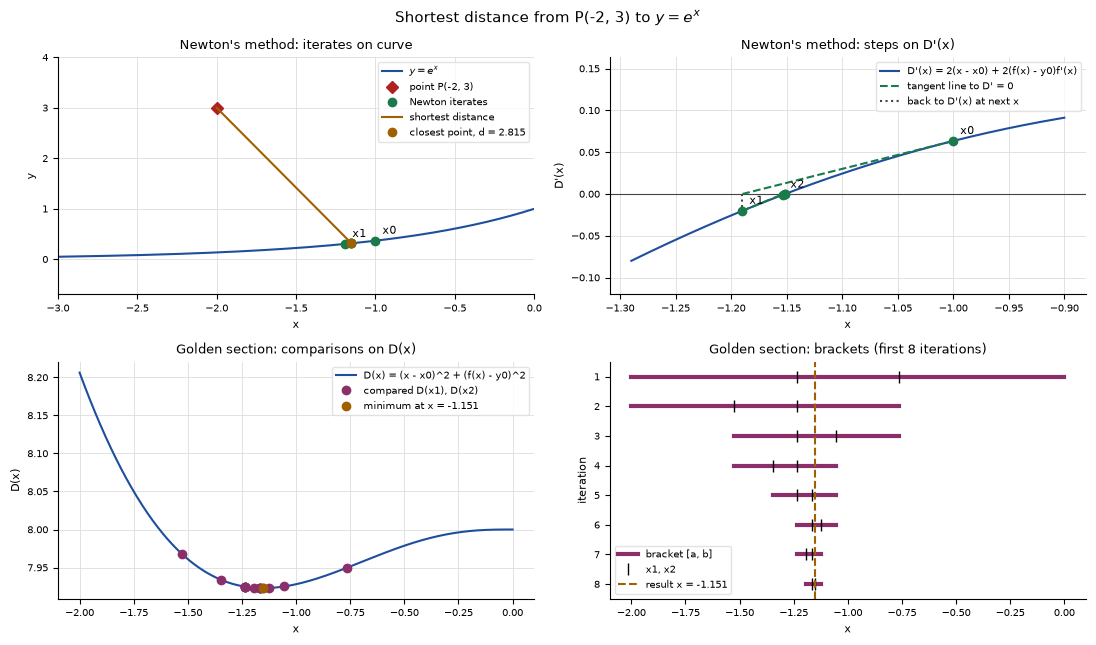

Newton d = 1.3068239334438294 x = 0.26364464022847317 steps = 4
Golden d = 1.3068239334438305 x = 0.2636446542167469 iters = 34


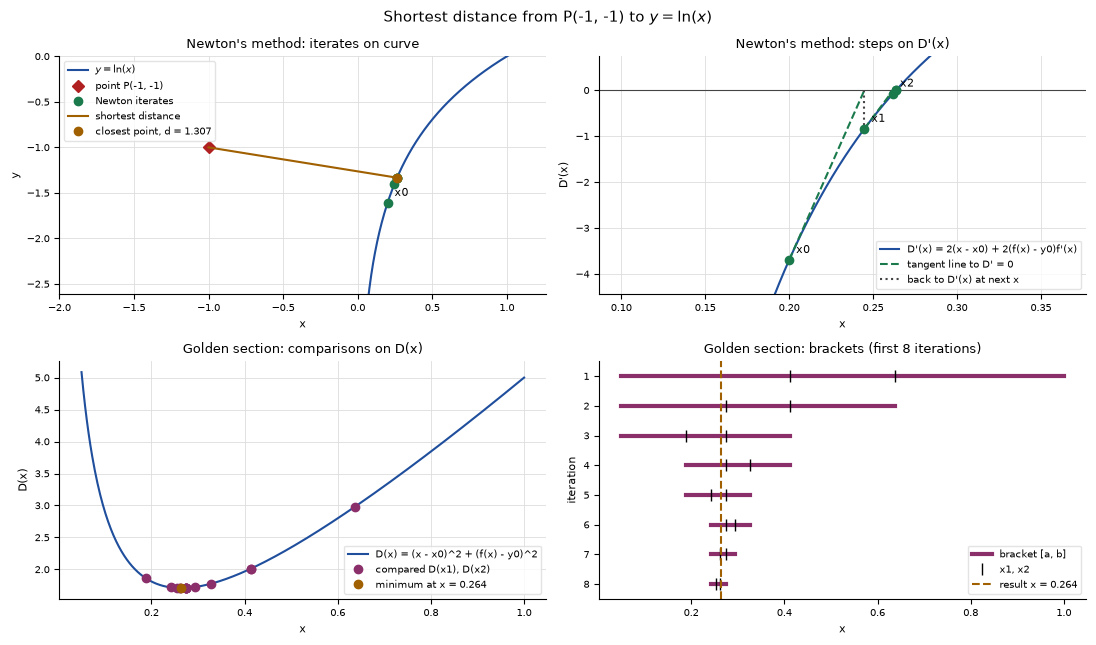

Newton d = 0.7485041972117096 x = 0.2530249903014252 steps = 5
Golden d = 0.7485041972104605 x = 0.2530250709820868 iters = 34


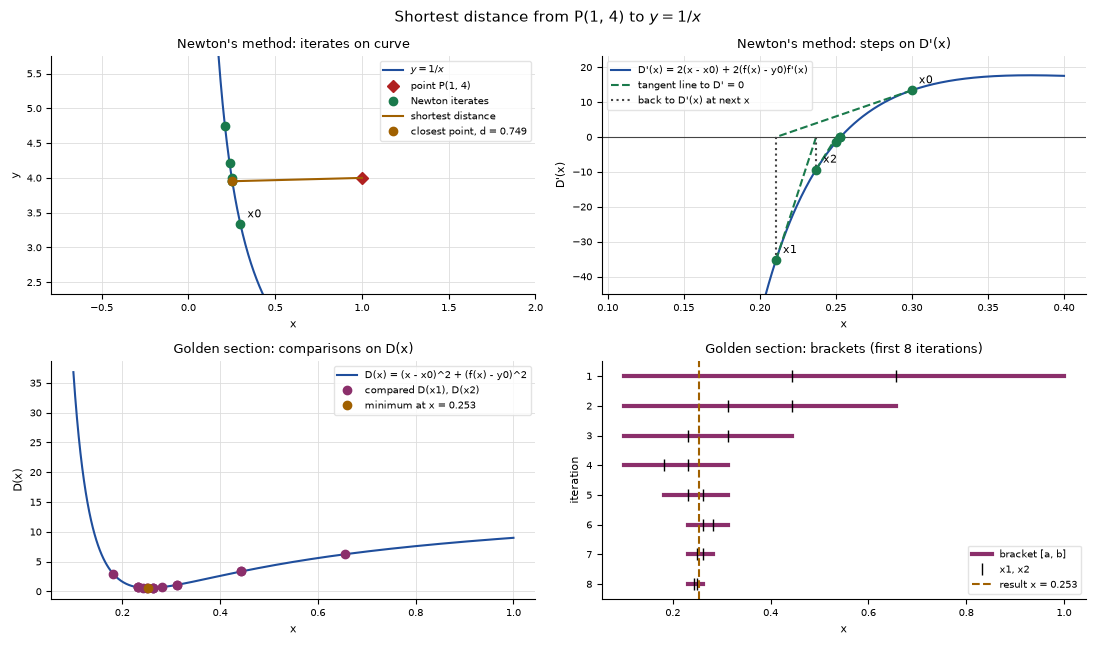

Newton d = 1.8344283958978749 x = 1.6631298072815484 steps = 4
Golden d = 1.8344283958978749 x = 1.6631298130861802 iters = 35


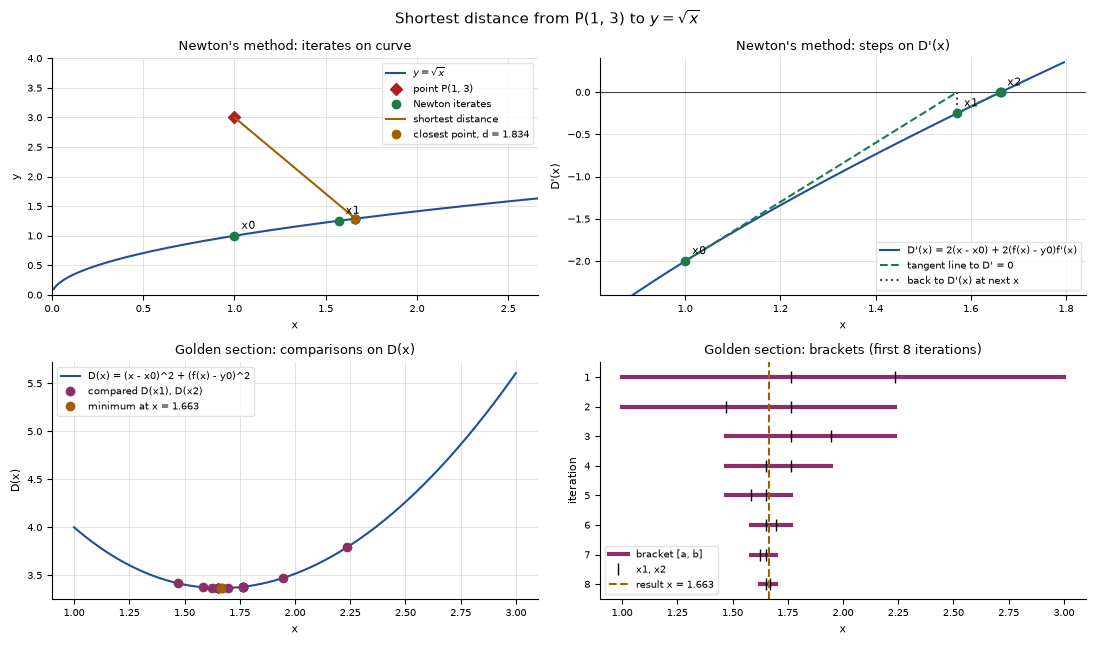

In [16]:
f_parab, df_parab, ddf_parab = make_parabola(2, -4, 1)
positive = (0, math.inf)

plot_cases = [
    (
        r"$y = x^2 + 5$",
        f,
        df,
        ddf,
        (0, 0),
        0.0,
        -1,
        1,
        (-math.inf, math.inf),
        "parabola_0_0.png",
    ),
    (
        r"$y = x^2 + 5$",
        f,
        df,
        ddf,
        (-4, 0),
        0.0,
        -4,
        0,
        (-math.inf, math.inf),
        "parabola_-4_0.png",
    ),
    (
        r"$y = x^2 + 5$",
        f,
        df,
        ddf,
        (-8, 0),
        0.0,
        -8,
        0,
        (-math.inf, math.inf),
        "parabola_-8_0.png",
    ),
    (
        r"$y = x^2 + 5$",
        f,
        df,
        ddf,
        (2, 0),
        0.0,
        0,
        2,
        (-math.inf, math.inf),
        "parabola_2_0.png",
    ),
    (
        r"$y = x^2 + 5$",
        f,
        df,
        ddf,
        (6, 0),
        0.0,
        0,
        6,
        (-math.inf, math.inf),
        "parabola_6_0.png",
    ),
    (
        r"$y = 2x^2 - 4x + 1$",
        f_parab,
        df_parab,
        ddf_parab,
        (-2, -3),
        0.0,
        -2,
        1,
        (-math.inf, math.inf),
        "parabola2_-2_-3.png",
    ),
    (
        r"$y = e^x$",
        math.exp,
        math.exp,
        math.exp,
        (-2, 3),
        -1,
        -2,
        0,
        (-math.inf, math.inf),
        "exp_-2_3.png",
    ),
    (
        r"$y = \ln(x)$",
        math.log,
        lambda x: 1 / x,
        lambda x: -1 / x**2,
        (-1, -1),
        0.2,
        0.05,
        1,
        positive,
        "ln_-1_-1.png",
    ),
    (
        r"$y = 1/x$",
        lambda x: 1 / x,
        lambda x: -1 / x**2,
        lambda x: 2 / x**3,
        (1, 4),
        0.3,
        0.1,
        1,
        positive,
        "reciprocal_1_4.png",
    ),
    (
        r"$y = \sqrt{x}$",
        math.sqrt,
        lambda x: 1 / (2 * math.sqrt(x)),
        lambda x: -1 / (4 * x**1.5),
        (1, 3),
        1,
        1,
        3,
        positive,
        "sqrt_1_3.png",
    ),
]

for (
    label,
    f_case,
    df_case,
    ddf_case,
    point,
    initial_guess,
    a,
    b,
    domain,
    filename,
) in plot_cases:
    plot_intermediate_steps(
        label,
        f_case,
        df_case,
        ddf_case,
        point,
        initial_guess,
        a,
        b,
        domain=domain,
        filename=filename,
    )

In [29]:
Points = [(0, 0.5), (1, 1.5), (2, 3.5), (3, 7.5)]

def MSE(points, coeffs):
    total = 0
    for x, y in points:
        diff = y
        for order, coeff in enumerate(coeffs):
            term = coeff * (x ** order)
            diff -= term

        total += diff ** 2

    return total / len(points)
    

In [30]:
def fit_polynominals(points, order):
    cols = []
    for power in range(order + 1):
        col = []
        for x, _ in points:
            col.append(x ** power)

        cols.append(col)

    A = np.column_stack(cols)
    b = np.array([y for _, y in points])

    ATA = A.T @ A
    ATb = A.T @ b
    coeffs = np.linalg.solve(ATA, ATb)

    return coeffs
    
    

coeffs = fit_polynominals(Points,3)
print(MSE(Points, coeffs))
        
    

1.2565171402470648e-28


In [31]:
def design_matrix(points, order):
    cols = []
    for power in range(order + 1):
        col = []
        for x, _ in points:
            col.append(float(x) ** power)

        cols.append(col)

    A = np.column_stack(cols)
    b = np.array([y for _, y in points], dtype=float)

    return A, b

print(design_matrix(Points, 2))

(array([[1., 0., 0.],
       [1., 1., 1.],
       [1., 2., 4.],
       [1., 3., 9.]]), array([0.5, 1.5, 3.5, 7.5]))


In [32]:
def fit_coordinate_newton(points, order, tolerance=1e-7, max_sweeps=10000):
    A, b = design_matrix(points, order)
    ATA = A.T @ A
    ATb = A.T @ b
    n = len(points)

    coeffs = np.zeros(order + 1)
    history = []
    sweeps = 0

    for sweep in range(max_sweeps):
        history.append(coeffs.copy())

        gradient = -(2 / n) * (ATb - ATA @ coeffs)
        if np.max(np.abs(gradient)) < tolerance:
            break

        for j in range(order + 1):
            g = -(2 / n) * (ATb[j] - ATA[j] @ coeffs)
            h = (2 / n) * ATA[j, j]

            coeffs[j] = coeffs[j] - g / h

        sweeps = sweep + 1

    return coeffs, sweeps

In [37]:
def fit_hessian_newton(points, order, tolerance=1e-7, max_iter=100):
    xs = np.array([x for x, _ in points], dtype=float)
    ys = np.array([y for _, y in points], dtype=float)
    n = len(points)

    # H[j][k] = d2MSE/(dc_j dc_k) = (2/n) * sum of x^(j+k)
    H = np.zeros((order + 1, order + 1))
    for j in range(order + 1):
        for k in range(order + 1):
            H[j, k] = (2 / n) * np.sum(xs ** (j + k))

    coeffs = np.zeros(order + 1)
    iterations = 0
    history = []

    for i in range(max_iter):
        history.append(coeffs.copy())

        predictions = np.zeros(n)
        for j in range(order + 1):
            predictions += coeffs[j] * xs**j

        residual = ys - predictions

        # gradient[j] = dMSE/dc_j = -(2/n) * sum of x^j * residual
        gradient = np.zeros(order + 1)
        for j in range(order + 1):
            gradient[j] = -(2 / n) * np.sum(xs**j * residual)

        if np.max(np.abs(gradient)) < tolerance:
            break

        s = np.linalg.solve(H, gradient)   # H s = grad MSE
        coeffs = coeffs - s                # c <- c - s
        iterations = i + 1

    return coeffs, iterations

In [38]:
for order, name in [(1, "line"), (2, "parabola")]:
    analytical = fit_polynominals(Points, order)
    coordinate, sweeps = fit_coordinate_newton(Points, order)
    hessian, iterations = fit_hessian_newton(Points, order)

    print(f"===== {name} =====")
    print(f"    analytical: {analytical}, MSE {MSE(Points, analytical):.6f}")
    print(f"    coordinate: {coordinate}, MSE {MSE(Points, coordinate):.6f}, {sweeps} sweeps")
    print(f"    hessian:    {hessian}, MSE {MSE(Points, hessian):.6f}, {iterations} iterations")

ValueError: too many values to unpack (expected 2, got 3)

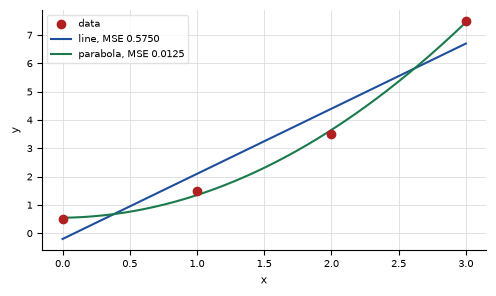

In [39]:
def plot_fits(points, filename=None):
    xs = np.array([x for x, _ in points], dtype=float)
    ys = np.array([y for _, y in points], dtype=float)
    grid = np.linspace(xs.min(), xs.max(), 200)

    fig, ax = plt.subplots(figsize=(5, 3))
    ax.scatter(xs, ys, color=POINT, zorder=3, label="data")

    for order, name, colour in [(1, "line", CURVE), (2, "parabola", NEWTON)]:
        coeffs, _ = fit_hessian_newton(points, order)

        curve = np.zeros_like(grid)
        for j, coeff in enumerate(coeffs):
            curve += coeff * grid**j

        ax.plot(grid, curve, color=colour, label=f"{name}, MSE {MSE(points, coeffs):.4f}")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()

    if filename:
        os.makedirs("media", exist_ok=True)
        fig.savefig("media/" + filename, dpi=110)
    plt.show()


plot_fits(Points, "fits.png")